# **Premessa statistica**
Dal punto di vista della statistica è importante fare una premessa terminologica.

Le variabili possono variare nel tempo e un fenomeno può dipendere da altre variabili (covariate) che variano anche queste nel tempo.

Si parla in questi casi di **dataset longitudinale** o anche **dati panel**.

Ecco i punti chiave:
Struttura: Ogni soggetto (i) viene osservato ripetutamente nel tempo (t), creando un dataset "lungo" (es. 100 persone osservate per 5 anni = 500 righe).

### **Tipi di Panel:**
- Bilanciato: Tutte le unità sono osservate in tutti i periodi temporali.
- Non bilanciato: Alcune osservazioni mancano per determinati periodi.

-Vantaggi: Ideali per studi su comportamenti, fedeltà alla marca o impatto di politiche nel tempo, poiché seguono il soggetto nel corso del tempo.
- Applicazioni: Ricerche di mercato (Nielsen), studi sull'audience (Auditel), indagini economiche (ISTAT).

I dati panel si distinguono da quelli "cross-section" (una foto istantanea di tanti soggetti) e dalle serie storiche (un solo soggetto nel tempo).

### **Curiosità:**
Il nome della libreria Python pandas deriva direttamente dal termine econometrico "Panel Data" (dati panel), che si riferisce a dataset strutturati contenenti osservazioni su più periodi di tempo per gli stessi soggetti000000



# Introduzione all’Analisi delle Serie Temporali

Per brevità faremo solo dei cenni ad alcuni degli aspetti di base delle serie tempororali.


Una **serie temporale** è una sequenza di osservazioni numeriche raccolte (o registrate) a **intervalli regolari** nel tempo.

Esempi classici:

- Vendite giornaliere/mensili di un prodotto
- Temperatura media giornaliera in una città
- Prezzo di chiusura di un’azione in borsa
- Consumi elettrici ogni 15 minuti
- Numero di visitatori su un sito web ogni ora
- Tasso di disoccupazione mensile
- Produzione industriale trimestrale
- Battiti cardiaci misurati ogni secondo

Caratteristica fondamentale: **l’ordine temporale è importante**.
Questo vuol dire che  non possiamo mischiare casualmente le osservazioni.

## Componenti principali di una serie temporale

La maggior parte delle serie temporali può essere scomposta (almeno concettualmente) in 4 parti:

| Componente       | Descrizione                                                                 | Esempio tipico                              | Matematicamente tendenzialmente...     |
|------------------|-----------------------------------------------------------------------------|---------------------------------------------|----------------------------------------|
| **Trend**        | Movimento di lungo periodo (crescita/decrescita lenta)                      | Aumento graduale delle temperature globali | additivo o moltiplicativo              |
| **Stagionalità** | Pattern che si ripete a intervallo fisso (giornaliero, settimanale, annuale)| Picchi di vendite natalizie ogni dicembre  | periodico fisso                        |
| **Ciclo**        | Oscillazioni di periodo variabile e non fisso (più lungo della stagionalità)| Cicli economici di 5–10 anni                | non fisso, non prevedibile con Fourier |
| **Rumore / residuo** | Variazioni casuali / imprevedibili / non spiegabili dagli altri componenti | Errori di misurazione, eventi eccezionali   | componente casuale / stocastica        |

Molto spesso si usa la scomposizione additiva:

```
Y_t = Trend_t + Stagionalità_t + Ciclo_t + Residuo_t
```

oppure moltiplicativa (più comune quando l’ampiezza cresce col tempo):

```
Y_t = Trend_t × Stagionalità_t × Ciclo_t × Residuo_t
```


Nel codice sotto vedremo un esempio in cui applicare entrambe le possibilità e riflettere sulle differenze.

##  Tipologie di serie temporali (classificazione utile)

| Tipo                        | Frequenza tipica          | Esempi                                      | Difficoltà di previsione |
|-----------------------------|----------------------------|---------------------------------------------|---------------------------|
| Molto alta frequenza        | secondi / minuti           | dati di sensori, trading ad alta frequenza  | ★★★★★                     |
| Alta frequenza              | oraria / giornaliera       | consumi elettrici, traffico web             | ★★★★                      |
| Media frequenza             | giornaliera / settimanale  | vendite al dettaglio, meteo                 | ★★★                       |
| Bassa frequenza             | mensile / trimestrale      | PIL, disoccupazione, indici macro           | ★★                        |
| Molto bassa frequenza       | annuale                    | popolazione, emissioni CO₂ storiche         | ★                         |

## Obiettivi principali nell’analisi delle serie temporali

Inseriamo qui questo elenco non esaustivo in modo che in una futura esperienza lavorativa un problema possa essere ricollegato allo strumento della serie temporale.

1. **Descrizione** → capire pattern, trend, stagionalità
2. **Previsione** (forecasting) → stimare valori futuri
3. **Anomaly detection** → trovare valori anomali / cambi di regime
4. **Decomposizione** → separare le componenti
5. **Analisi di correlazione temporale** → autocorrelazione, cross-correlazione
6. **Modellazione causale** → capire relazioni tra più serie (VAR, VECM…)
7. **Intervento / valutazione impatto** → es. effetto di una campagna marketing

## 5. Concetti fondamentali da conoscere

| Concetto                     | Significato breve                                                                 | Perché è importante?                                 |
|------------------------------|-----------------------------------------------------------------------------------|------------------------------------------------------|
| **Stazionarietà**            | Media, varianza e covarianza non cambiano nel tempo                              | Molti modelli classici (ARIMA) la richiedono        |
| **Autocorrelazione (ACF)**   | Correlazione tra la serie e se stessa spostata di k passi                        | Serve per identificare ordine di AR e MA            |
| **Autocorrelazione parziale (PACF)** | Correlazione dopo aver eliminato l’effetto dei lag intermedi               | Aiuta a scegliere ordine AR                         |
| **Differenziazione**         | y'_t = y_t − y_{t−1}                                                             | Trasforma serie non stazionaria in stazionaria     |
| **Stagionalità**             | Pattern periodico ripetitivo                                                     | Deve essere modellata o rimossa prima di ARIMA      |
| **Cambi di regime / breakpoint** | Cambi improvvisi di media/varianza/trend                                   | Molti modelli falliscono se non li gestiamo         |

## Pipeline tipica di analisi (flusso consigliato)

1. **Importazione e pulizia**  
   (missing values, duplicati, allineamento temporale)

2. **Visualizzazione esplorativa**  
   - Plot della serie  
   - Plot stagionale  
   - Boxplot per mese/giorno della settimana  
   - Decomposizione classica / STL

3. **Verifica stazionarietà**  
   - Test ADF / KPSS  
   - Plot ACF/PACF

4. **Trasformazioni** se necessario  
   - Log, radice quadrata  
   - Differenziazione (d)  
   - Rimozione stagionalità (D)

5. **Scelta e stima del modello**  

Questa parte per motivi di tempo non è stata trattata ma la riportiamo perché centrale. E' possibile utilizzare anche in questo ambito alcune competenze acquisite nel campo del Machine Learning:

   - ARIMA / SARIMA  
   - Exponential Smoothing  
   - Prophet  
   - modelli ML (XGBoost, LightGBM con lag)  
   - reti neurali (LSTM, Transformer, N-BEATS…)

6. **Validazione**  
   - Train / Validation / Test split **temporale** (no random split!)  
   - Cross-validation rolling / expanding window

7. **Previsione e valutazione**  
   - MAE, RMSE, MAPE, sMAPE, MASE…

8. **Interpretazione e comunicazione**



/tmp/ipykernel_1251/1109026340.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date = pd.date_range(start="1949-01", periods=len(data), freq="M")


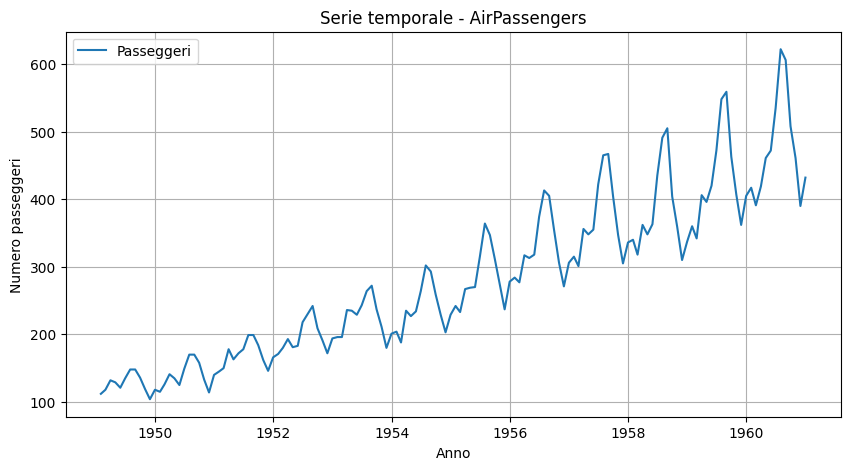

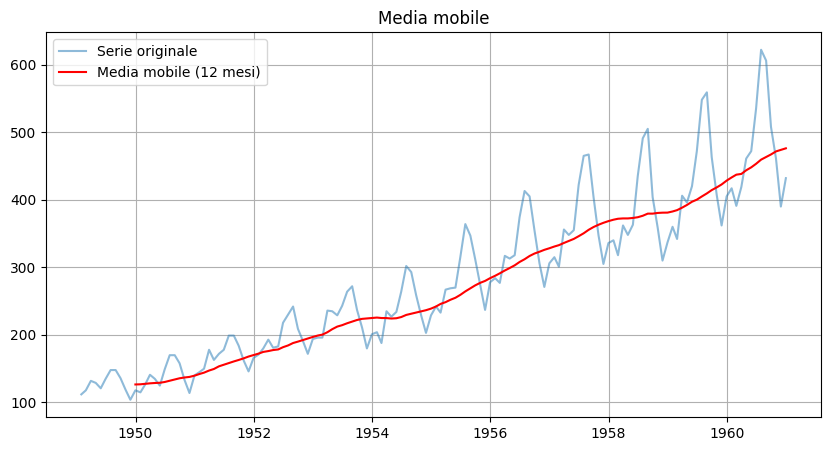

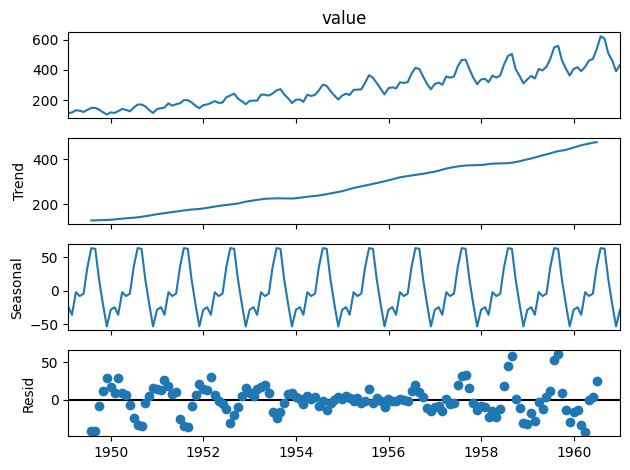

            value  moving_avg       trend   seasonal   residual
date                                                           
1949-01-31    112         NaN         NaN -24.748737        NaN
1949-02-28    118         NaN         NaN -36.188131        NaN
1949-03-31    132         NaN         NaN  -2.241162        NaN
1949-04-30    129         NaN         NaN  -8.036616        NaN
1949-05-31    121         NaN         NaN  -4.506313        NaN
1949-06-30    135         NaN         NaN  35.402778        NaN
1949-07-31    148         NaN  126.791667  63.830808 -42.622475
1949-08-31    148         NaN  127.250000  62.823232 -42.073232
1949-09-30    136         NaN  127.958333  16.520202  -8.478535
1949-10-31    119         NaN  128.583333 -20.642677  11.059343
1949-11-30    104         NaN  129.000000 -53.593434  28.593434
1949-12-31    118  126.666667  129.750000 -28.619949  16.869949
1950-01-31    115  126.916667  131.250000 -24.748737   8.498737
1950-02-28    126  127.583333  133.08333

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from statsmodels.tsa.seasonal import seasonal_decompose

# =========================
# 1. CARICAMENTO DATASET
# =========================
data = get_rdataset("AirPassengers").data

# Costruzione serie temporale
date = pd.date_range(start="1949-01", periods=len(data), freq="M")
df = pd.DataFrame({
    "date": date,
    "value": data["value"]
})

df.set_index("date", inplace=True)

# =========================
# 2. GRAFICO SERIE TEMPORALE
# =========================
plt.figure(figsize=(10,5))
plt.plot(df.index, df["value"], label="Passeggeri")
plt.title("Serie temporale - AirPassengers")
plt.xlabel("Anno")
plt.ylabel("Numero passeggeri")
plt.legend()
plt.grid()
plt.show()

# =========================
# 3. MEDIA MOBILE
# =========================
window = 12  # stagionalità annuale (dati mensili)
df["moving_avg"] = df["value"].rolling(window=window).mean()

plt.figure(figsize=(10,5))
plt.plot(df.index, df["value"], label="Serie originale", alpha=0.5)
plt.plot(df.index, df["moving_avg"], label="Media mobile (12 mesi)", color="red")
plt.title("Media mobile")
plt.legend()
plt.grid()
plt.show()

# =========================
# 4. TREND E STAGIONALITÀ
# =========================
#result = seasonal_decompose(df["value"], model="multiplicative", period=12)

result = seasonal_decompose(df["value"], model="additive", period=12)

result.plot()
plt.show()

# =========================
# 5. COMPONENTI
# =========================
df["trend"] = result.trend
df["seasonal"] = result.seasonal
df["residual"] = result.resid

print(df.head(15))

In [ ]:
data = get_rdataset("AirPassengers").data
type(data)

data.columns

Index(['time', 'value'], dtype='object')

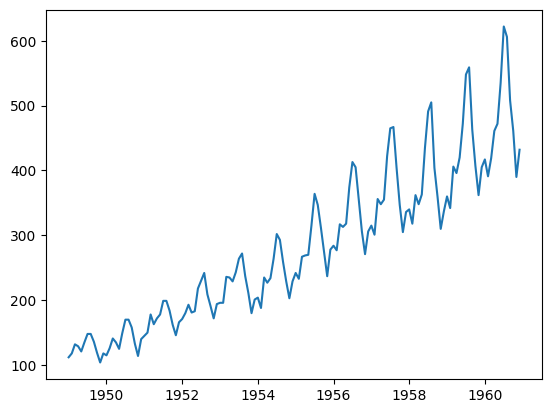

In [ ]:
plt.plot(data['time'], data['value'])
plt.show()

In [ ]:
data.head()

,time,value
0,1949.000000,112
1,1949.083333,118
2,1949.166667,132
3,1949.250000,129
4,1949.333333,121
